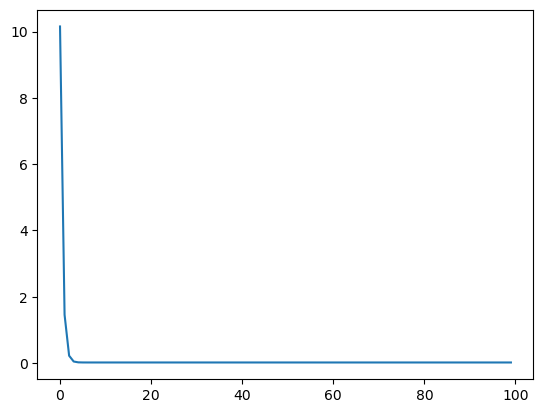

In [ ]:
import torch
from matplotlib import pyplot as plt

x = torch.tensor( [12.4, 14.3, 14.5, 14.9, 16.1, 16.9, 16.5, 15.4, 17.0, 17.9, 18.8, 20.3, 22.4,
19.4, 15.5, 16.7, 17.3, 18.4, 19.2, 17.4, 19.5, 19.7, 21.2])
y = torch.tensor( [11.2, 12.5, 12.7, 13.1, 14.1, 14.8, 14.4, 13.4, 14.9, 15.6, 16.4, 17.7, 19.6,
16.9, 14.0, 14.6, 15.1, 16.1, 16.8, 15.2, 17.0, 17.2, 18.6])

b = torch.tensor(1., requires_grad=True)
w = torch.tensor(1., requires_grad=True)

alpha = torch.tensor(0.001)
loss_list = []

for epochs in range(100):
    loss = torch.mean((w * x + b - y) ** 2)
    loss_list.append(loss.item())
    loss.backward()
    with torch.no_grad():
        w -= alpha * w.grad
        b -= alpha * b.grad
    w.grad.zero_()
    b.grad.zero_()

plt.plot(loss_list)
plt.show()

In [ ]:
w = torch.tensor(1., requires_grad=True)
b = torch.tensor(1., requires_grad=True)
x = torch.tensor([2,4])
y = torch.tensor([20, 40])
alpha = torch.tensor(0.001)
for epoch in range(2):
    error = w * x + b - y
    loss = torch.mean(error ** 2)
    loss.backward()
    with torch.no_grad():
        dl_dw = (2/len(x)) * torch.sum(error * x) 
        dl_db = (2/len(x)) * torch.sum(error)
        print(w.grad, dl_dw, b.grad, dl_db)
        w -= alpha * w.grad
        b -= alpha * b.grad
        w.grad.zero_()
        b.grad.zero_()

tensor(-174.) tensor(-174.) tensor(-52.) tensor(-52.)
tensor(-170.2080) tensor(-170.2080) tensor(-50.8520) tensor(-50.8520)


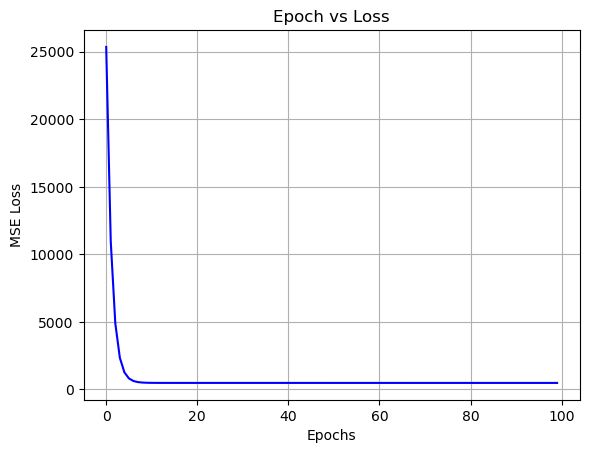

Final Parameters: w = 12.8508, b = 2.1500


In [14]:
import torch
import matplotlib.pyplot as plt

class RegressionModel:
    def __init__(self):
        self.w = torch.tensor(1.0, requires_grad=True)
        self.b = torch.tensor(1.0, requires_grad=True)
        self.learning_rate = torch.tensor(0.001)

    def forward(self, x):
        return self.w * x + self.b

    def criterion(self, y, yp):
        return torch.mean((yp - y) ** 2)

    def update(self):
        with torch.no_grad():
            self.w -= self.learning_rate * self.w.grad
            self.b -= self.learning_rate * self.b.grad

    def reset_grad(self):
        if self.w.grad is not None:
            self.w.grad.zero_()
        if self.b.grad is not None:
            self.b.grad.zero_()

x = torch.tensor([5.0, 7.0, 12.0, 16.0, 20.0])
y = torch.tensor([40.0, 120.0, 180.0, 210.0, 240.0])

# Training Loop
model = RegressionModel()
loss_list = []

for epoch in range(100):
    model.reset_grad()          
    yp = model.forward(x)       
    loss = model.criterion(y, yp) 
    
    loss_list.append(loss.item())
    
    loss.backward()             
    model.update()              

plt.plot(range(100), loss_list, color='blue')
plt.title("Epoch vs Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

print(f"Final Parameters: w = {model.w.item():.4f}, b = {model.b.item():.4f}")


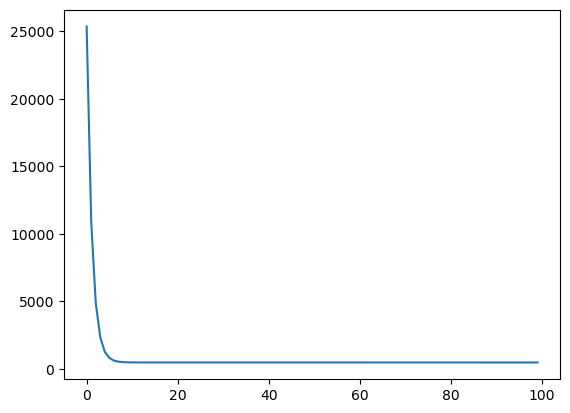

Final w: 12.8508
Final b: 2.1500


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

class RegressionModel(nn.Module):
    def __init__(self):
        super(RegressionModel, self).__init__()
        self.linear = nn.Linear(in_features=1, out_features=1)
        
        with torch.no_grad():
            self.linear.weight.fill_(1.0)
            self.linear.bias.fill_(1.0)

    def forward(self, x):
        return self.linear(x)

x = torch.tensor([5.0, 7.0, 12.0, 16.0, 20.0]).view(-1, 1)
y = torch.tensor([40.0, 120.0, 180.0, 210.0, 240.0]).view(-1, 1)

dataset = TensorDataset(x, y)
dataloader = DataLoader(dataset, batch_size=5, shuffle=True)

model = RegressionModel()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

loss_list = []

for epoch in range(100):
    for inputs, targets in dataloader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        optimizer.zero_grad() 
        loss.backward()
        optimizer.step()      
        
    loss_list.append(loss.item())

plt.plot(range(100), loss_list)
plt.show()

print(f"Final w: {model.linear.weight.item():.4f}")
print(f"Final b: {model.linear.bias.item():.4f}")


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

X = torch.tensor([[3.0, 8.0], [4.0, 5.0], [5.0, 7.0], [6.0, 3.0], [2.0, 1.0]])
Y = torch.tensor([[-3.7], [3.5], [2.5], [11.5], [5.7]])

model = nn.Linear(2, 1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(2000):
    yp = model(X)
    loss = criterion(yp, Y)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

w1, w2 = model.weight[0]
b = model.bias.item()
test_point = torch.tensor([[3.0, 2.0]])
with torch.no_grad():
    prediction = model(test_point)
print(f"Prediction for X1=3, X2=2: {prediction.item():.2f}")



Prediction for X1=3, X2=2: 6.28


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

x = torch.tensor([1, 5, 10, 10, 25, 50, 70, 75, 100], dtype=torch.float32).view(-1, 1)
y = torch.tensor([0, 0, 0, 0, 0, 1, 1, 1, 1], dtype=torch.float32).view(-1, 1)

dataset = TensorDataset(x, y)
dataloader = DataLoader(dataset, batch_size=len(x)) 

# 2. Model Definition
class LogisticRegression(nn.Module):
    def __init__(self):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(1, 1)
        self.sigmoid = nn.Sigmoid() # Squashes output to [0, 1]

    def forward(self, x):
        return self.sigmoid(self.linear(x))

model = LogisticRegression()

criterion = nn.BCELoss() 
optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(1000):
    for inputs, targets in dataloader:
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/1000], Loss: {loss.item():.4f}')

# 5. Prediction Verification
with torch.no_grad():
    test_val = torch.tensor([[30.0]])
    prediction = model(test_val)
    print(f"\nProbability for x=30: {prediction.item():.4f}")
    print(f"Class Prediction: {1 if prediction.item() > 0.5 else 0}")


Epoch [200/1000], Loss: 0.4265
Epoch [400/1000], Loss: 0.3408
Epoch [600/1000], Loss: 0.2852
Epoch [800/1000], Loss: 0.2450
Epoch [1000/1000], Loss: 0.2150

Probability for x=30: 0.5475
Class Prediction: 1
